# 1. Import libraries and data

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
from wifiplotting import plot_wifi_heatmap

In [143]:
wifi_df = pd.read_csv('../data/df_clean.csv')

In [144]:
wifi_df.head(5)

,date,time_pdt,latitude,longitude,indoor,floor,rssi,noise,signal_measured,datetime
0,2026-04-09,20:37:57,37.427721,-122.15586,True,3,-58.0,-98.0,True,2026-04-09 20:37:57-07:00
1,2026-04-09,20:37:57,37.427721,-122.15586,True,3,-57.0,-98.0,True,2026-04-09 20:37:57-07:00
2,2026-04-09,20:37:57,37.427721,-122.15586,True,3,-57.0,-98.0,True,2026-04-09 20:37:57-07:00
3,2026-04-09,20:39:47,37.427721,-122.15586,True,3,-58.0,-98.0,True,2026-04-09 20:39:47-07:00
4,2026-04-09,20:39:47,37.427721,-122.15586,True,3,-58.0,-98.0,True,2026-04-09 20:39:47-07:00


In [161]:
# filter for data in sequoia area

tl_corner = [37.430582, -122.173904]
br_corner = [37.42705, -122.169413]
sequoia = (br_corner[0] <= wifi_df['latitude']) &  (wifi_df['latitude'] <= tl_corner[0]) & \
            (tl_corner[1] <= wifi_df['longitude']) & (wifi_df['longitude'] <= br_corner[1])

wifi_df = wifi_df[sequoia]

In [148]:
## plot corner points to see where to sample
# wifi_df.loc[len(wifi_df)] = [np.nan, np.nan, tl_corner[0], tl_corner[1], False, 0, 0, 0, True, np.nan]
# wifi_df.loc[len(wifi_df)] = [np.nan, np.nan, br_corner[0], br_corner[1], False, 0, 0, 0, True, np.nan]

# 2. Some exploratory plots

OSM building footprints unavailable (HTTP Error 400: Bad Request).
RSSI heatmap uses 42 unique coordinate bins from 140 rows.


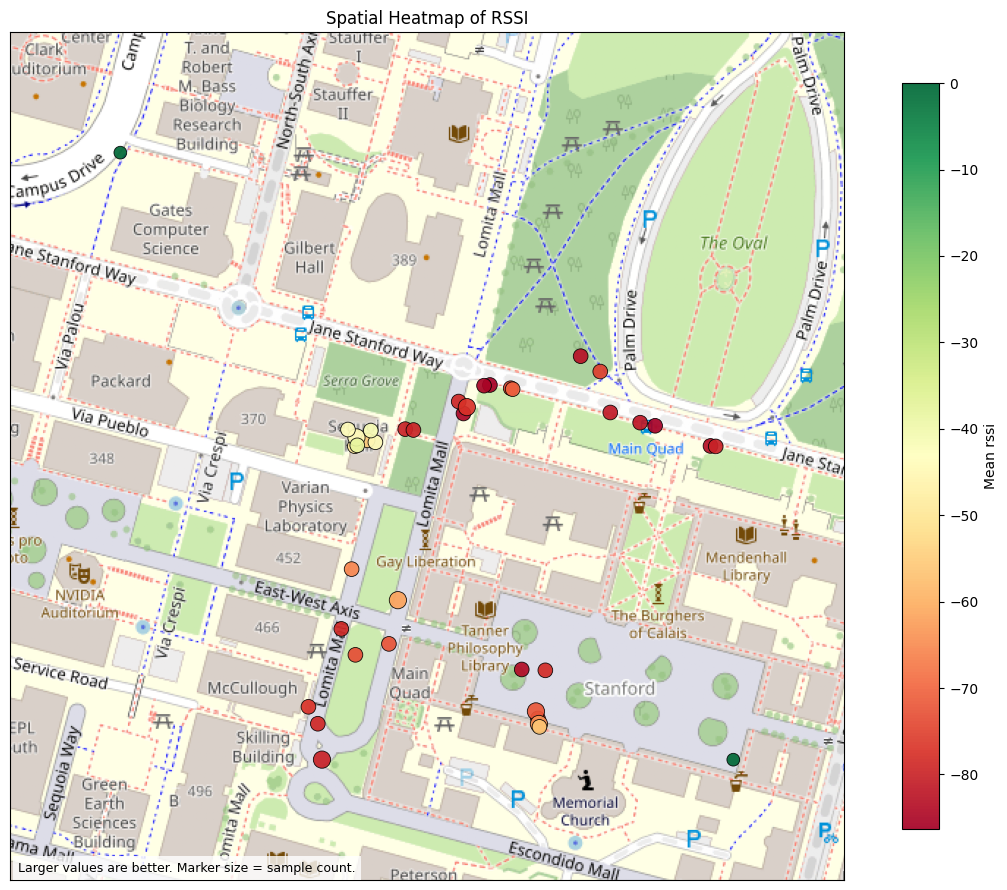

In [149]:
fig, ax, rssi_points = plot_wifi_heatmap(wifi_df)
rows_used = int(rssi_points["sample_count"].sum())
print(f"RSSI heatmap uses {len(rssi_points)} unique coordinate bins from {rows_used} rows.")
plt.show()

OSM building footprints unavailable (HTTP Error 400: Bad Request).
Noise heatmap uses 42 unique coordinate bins from 140 rows.


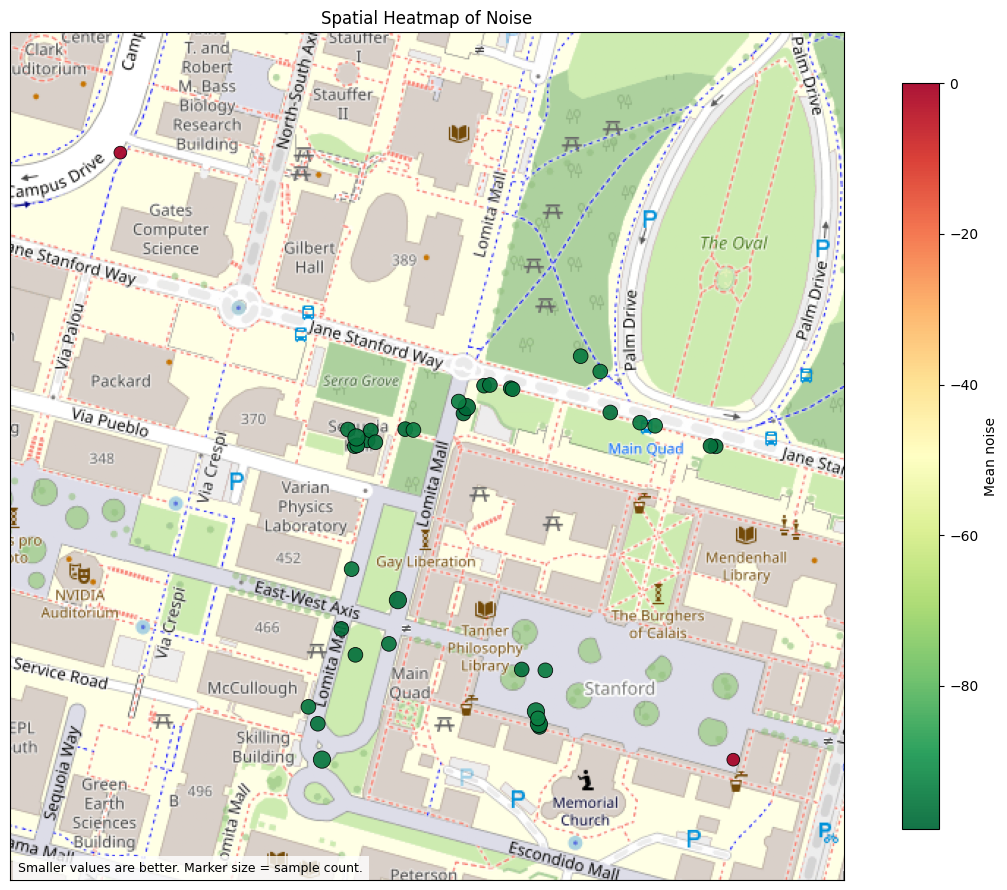

In [150]:
fig, ax, noise_points = plot_wifi_heatmap(wifi_df, value="noise", invert_cmap=True)
rows_used = int(noise_points["sample_count"].sum())
print(f"Noise heatmap uses {len(noise_points)} unique coordinate bins from {rows_used} rows.")
plt.show()

In [151]:
snr = wifi_df.rssi - wifi_df.noise

OSM building footprints unavailable (HTTP Error 400: Bad Request).
SNR heatmap uses 42 unique coordinate bins from 140 rows.


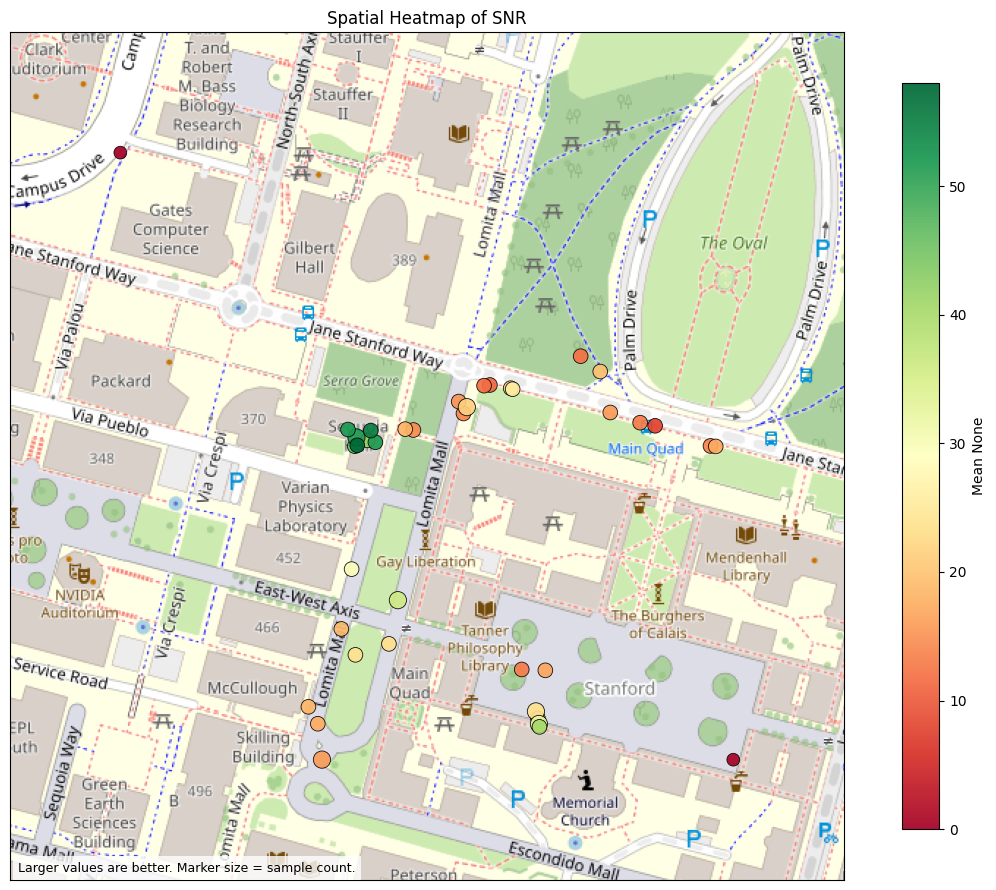

In [152]:
fig, ax, snr_points = plot_wifi_heatmap(wifi_df, new_data=snr, plotname='SNR')
rows_used = int(snr_points["sample_count"].sum())
print(f"SNR heatmap uses {len(snr_points)} unique coordinate bins from {rows_used} rows.")
plt.show()

# 3. Indoors vs. outdoors

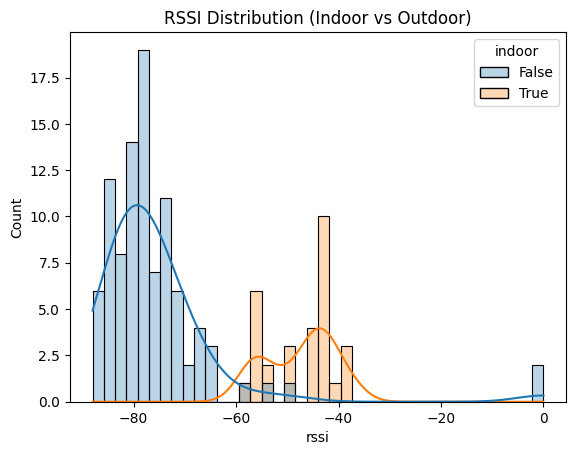

In [153]:
sns.histplot(data=wifi_df, x="rssi", hue="indoor", bins=40, kde=True, alpha=0.3)
plt.title("RSSI Distribution (Indoor vs Outdoor)")
plt.show()

# 4. Time of day

Main idea: we know that we should model location and indoor/outdoor, but should we model time? We check by doing simple KNN for location and indoor/outdoor, then seeing if the residuals have any relation to time of day.

Potential problem: because of sampling design, it is possible location and time are correlated.

In [154]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [155]:
wifi_df.head(5)

,date,time_pdt,latitude,longitude,indoor,floor,rssi,noise,signal_measured,datetime
6,2026-04-10,12:29:18,37.428897,-122.172035,True,3,-45.0,-96.0,True,2026-04-10 12:29:18-07:00
7,2026-04-10,12:29:18,37.428897,-122.172035,True,3,-44.0,-96.0,True,2026-04-10 12:29:18-07:00
8,2026-04-10,12:29:18,37.428897,-122.172035,True,3,-44.0,-96.0,True,2026-04-10 12:29:18-07:00
9,2026-04-10,12:31:58,37.428971,-122.172236,True,2,-44.0,-96.0,True,2026-04-10 12:31:58-07:00
10,2026-04-10,12:31:58,37.428971,-122.172236,True,2,-44.0,-96.0,True,2026-04-10 12:31:58-07:00


In [156]:
numeric_to_scale = ["latitude", "longitude"]   # columns that need normalization

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), numeric_to_scale),
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", KNeighborsRegressor())
])

param_grid = {
    "model__n_neighbors": np.arange(1, 21),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]  # Manhattan vs Euclidean
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",  # or "r2"
    n_jobs=-1,   # use all CPU cores
    verbose=0
)

In [157]:
df_knn = wifi_df[wifi_df['rssi'].notna()].copy()
# aggregate duplicate X values
df_knn = df_knn.groupby(["latitude", "longitude", "indoor"], as_index=False)["rssi"].mean()
grid.fit(df_knn[["latitude", "longitude", "indoor"]], df_knn["rssi"])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': array([ 1, 2... 18, 19, 20]), 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [158]:
print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'model__n_neighbors': np.int64(1), 'model__p': 2, 'model__weights': 'uniform'}
Best score: -326.38402777777776


In [159]:
grid.best_score_

np.float64(-326.38402777777776)

In [160]:
residuals = wifi_df["rssi"] - grid.best_estimator_.predict(wifi_df[["latitude", "longitude", "indoor"]])
time_sec = wifi_df["time_pdt"].apply(lambda t: int((hms := t.split(':'))[0])*3600 + int(hms[1])*60 + int(hms[2]))

AttributeError: 'float' object has no attribute 'split'

We now visualize residuals vs. time. To get more reasonable results, we will drop the extreme outliers along both axes.

In [90]:
mask = (time_sec >= 20000) & (residuals >= -30) & (residuals <= 30)

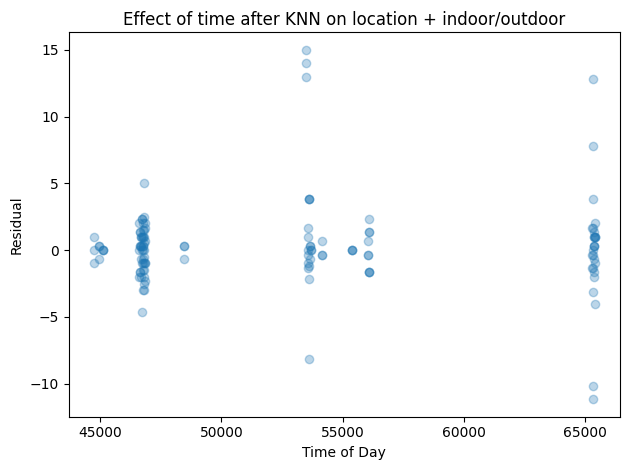

In [91]:
plt.scatter(time_sec[mask], residuals[mask], alpha=0.3)
plt.xlabel('Time of Day')
plt.ylabel('Residual')
plt.title('Effect of time after KNN on location + indoor/outdoor')
plt.tight_layout()

There doesn't seem to be any meaningful relationship. We will check with a linear regression.

In [92]:
from sklearn.linear_model import LinearRegression

In [93]:
lr = LinearRegression()
lr.fit(time_sec[mask].values.reshape(-1,1), residuals[mask])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
print(f"Fitted Intercept: {lr.intercept_}")
print(f"Fitted Slope: {lr.coef_[0]}")

Fitted Intercept: 0.16882024386994765
Fitted Slope: 3.155666355278413e-06


# 5. Noise distribution

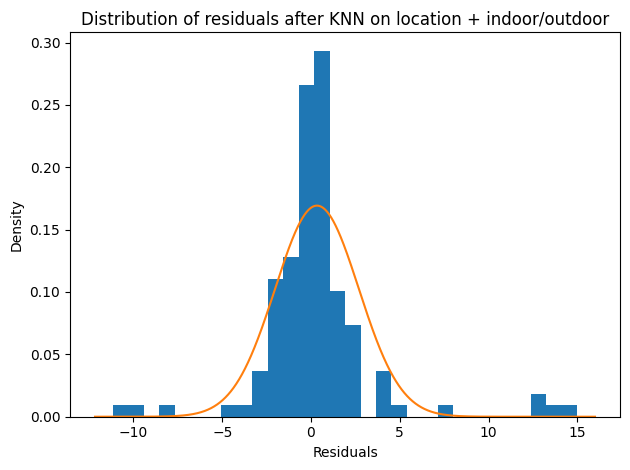

In [95]:
plt.hist(residuals[mask], bins=30, density=True)

norm_approx = sp.stats.norm(loc=residuals[mask].mean(), scale=residuals[mask].std()-1)
density_grid = np.arange(residuals[mask].min()-1, residuals[mask].max()+1, 1e-3)
plt.plot(density_grid, norm_approx.pdf(density_grid))

plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Distribution of residuals after KNN on location + indoor/outdoor')
plt.tight_layout()